<a href="https://colab.research.google.com/github/Yahir-7/Data_Center_GeoPandas/blob/main/_Bachelor_Degree_or_Higher_bar_graph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_3850/3927671150.py:10: DtypeWarning: Columns (51,307,563) have mixed types. Specify dtype option on import or set low_memory=False.
  census = pd.read_csv(file, header=1)


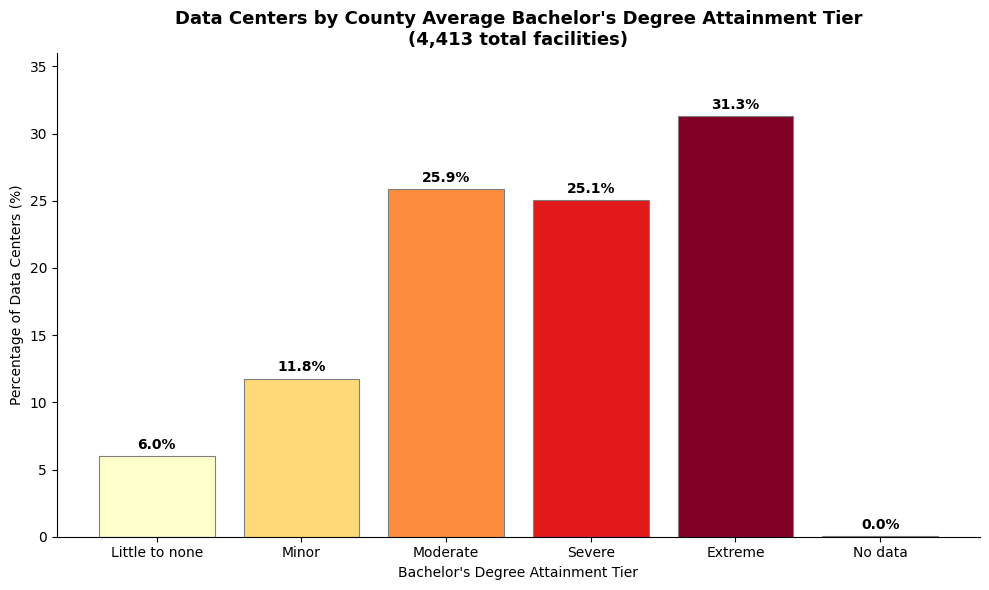

In [1]:
# Run once
!pip install numpy pandas matplotlib openpyxl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

file = "/content/ACSST5Y2024.S1501-Data.csv"

census = pd.read_csv(file, header=1)
census["TRACT_GEOID"] = census["Geography"].astype(str).str.split("US").str[-1].str.strip()

# FIPS for data
census["FIPS"] = census["TRACT_GEOID"].str[:5]

education_col = [c for c in census.columns if "Percent" in c and "Bachelor's degree or higher" in c and "Population 25 years and over" in c]
target_col = education_col[0]

census["Data_Value"] = pd.to_numeric(census[target_col], errors="coerce")

# avg education
education = (census.dropna(subset=["Data_Value"])
    .groupby("FIPS", as_index=False)["Data_Value"].mean())

# data center locations
facilities_file = "/content/facilities_final_complete.xlsx"

facilities = pd.read_excel(
    facilities_file,
    sheet_name="facilities_final_complete")

# FIPS for the facilities
facilities["fips"] = facilities["fips"].astype(int).astype(str).str.zfill(5)

total_facility_count = len(facilities)

# scale for the bins
education_values = education["Data_Value"].dropna()
vmin = education_values.quantile(0.02)
vmax = education_values.quantile(0.98)
bins = np.linspace(vmin, vmax, 6)

education["edu_bin"] = pd.cut(
    education["Data_Value"],
    bins=bins,
    labels=False,
    include_lowest=True)

# out-of-range values
education.loc[education["Data_Value"] < vmin, "edu_bin"] = 0
education.loc[education["Data_Value"] > vmax, "edu_bin"] = 4

# facility match to tiers
facility_tiers = facilities.merge(
    education[["FIPS", "edu_bin"]],
    left_on="fips",
    right_on="FIPS",
    how="left")

# tier names and colors
tier_names = ["Little to none", "Minor", "Moderate", "Severe", "Extreme"]
tier_colors = ["#FFFFCC", "#FED976", "#FD8D3C", "#E31A1C", "#800026"]
missing_color = "#D9D9D9"

# data center count
counts = [(facility_tiers["edu_bin"] == i).sum() for i in range(5)]
no_data_count = facility_tiers["edu_bin"].isna().sum()

labels = tier_names + ["No data"]
values = counts + [no_data_count]
colors = tier_colors + [missing_color]

# percentages
percentages = [v / total_facility_count * 100 for v in values]

# plot
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    labels,
    percentages,
    color=colors,
    edgecolor="#7f7f7f",
    linewidth=0.8)

# label
for bar, pct in zip(bars, percentages):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(percentages) * 0.01,
        f"{pct:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold")

ax.set_title(
    f"Data Centers by County Average Bachelor's Degree Attainment Tier\n({total_facility_count:,} total facilities)",
    fontsize=13,
    fontweight="bold")
ax.set_xlabel("Bachelor's Degree Attainment Tier")
ax.set_ylabel("Percentage of Data Centers (%)")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_ylim(0, max(percentages) * 1.15)

plt.tight_layout()
plt.show()